# Imports:

In [31]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.colors import PowerNorm

col_list = sns.color_palette("colorblind", 100)

import tqdm

from aq_gnome.data_handler import Data_Handler
from aq_gnome.visualization import plot_periodic_table_with_values, get_col_dict_for_atoms
from aq_gnome.stability import Stable_Entries, Stability_Criteria

dh = Data_Handler(solid_filter = True, gga_only = False, path_to_data_directory = None)
pHs = np.linspace(-2, 16, 19) # Data specific
Us = np.linspace(-2, 4, 31) # Data specific

List of elements to exclude:

In [32]:
elements_to_exclude = ['Tc',  'Ra', 'Rf', 'Db', 'Sg', 'Bh', 'Hs', 'Cl',
                        'Mt', 'Ds', 'Rg', 'Cn', 'Nh', 'Fl', 'Mc', 'Lv',
                        'Ts', 'Og', 'Pm', 'Ac', 'Th', 'Pa', 'U', 'Np', 
                        'Pu', 'Am', 'Cm', 'Bk', 'Cf', 'Es', 'Fm', 'Md',
                        'No', 'Lr', 'Po', 'At', 'Rn', 'Li', 'Na', 'K',
                        'Rb', 'Cs', 'Fr', 'Ca', 'Ba', 'Tl', 'Pb', 'As',
                        'Cd', 'Hg', 'P', 'F', 'Se', 'Te', 'B', 'C', 'S']

# 2D Histrograms

### Database setup:

In [33]:

# Options: "Main", "SI_DeltaG<02", "SI_excluding_elements<05", "SI_excluding_elements<02"
figure_type = 'SI_excluding_elements<02' # Main text 6 histrograms figure

if figure_type == 'Main':
    SC = .5 # Stability Criteria
    disregard_atoms = False
elif figure_type == 'SI_DeltaG<02':
    SC = .2 # Stability Criteria
    disregard_atoms = False
elif figure_type == 'SI_excluding_elements<05':
    SC = .5 # Stability Criteria
    disregard_atoms = True
elif figure_type == 'SI_excluding_elements<02':
    SC = .2 # Stability Criteria
    disregard_atoms = True

### Inclusion/exclusion of elements:

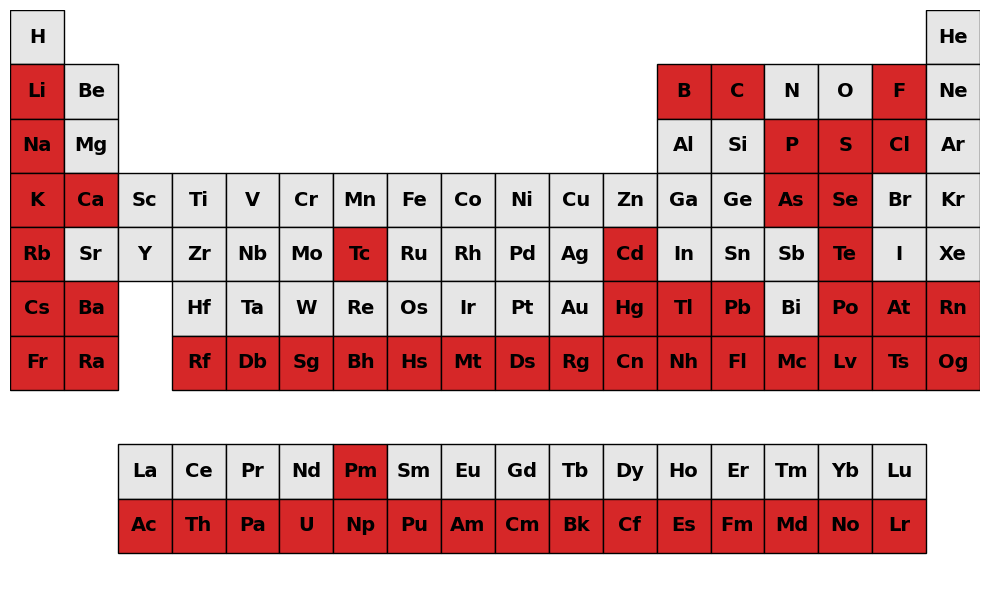

Number of entries removed: 283529 Number of entries left: 245442 which is 46.40% of total GNoME database


In [34]:
plot_periodic_table_with_values(
    get_col_dict_for_atoms(
        elements_to_discard = elements_to_exclude if disregard_atoms else []
        )
)

dh.restore_df()
dh.remove_entries_with_elements(elements_to_exclude if disregard_atoms else [])

### Discarding materials based on element selection

In [35]:
se = Stable_Entries(dh, [])

count = np.zeros((31, 19))
count_crystalline = np.zeros((31, 19))
O_line_count = np.zeros((31, 19))
H_line_count = np.zeros((31, 19))
O_line_count_ordered = np.zeros((31, 19))
H_line_count_ordered = np.zeros((31, 19))

# Maps to the Us array:
O_line_indices = np.array([17, 16, 16, 16, 16, 15, 15, 15, 14, 14, 14, 
                           13, 13, 13, 13, 12, 12, 12, 11])
H_line_indices = np.array([11, 10, 10, 10,  9,  9,  9,  9,  8,  8,  8, 
                            7,  7,  7,  6,  6,  6, 6,  5])

def keep_contiguous_ones(arr, idx):
    # If selected index is not 1 → return all zeros
    if arr[idx] == 0:
        return np.zeros_like(arr)

    # Find left boundary
    left = idx
    while left > 0 and arr[left - 1] == 1:
        left -= 1

    # Find right boundary
    right = idx
    while right < len(arr) - 1 and arr[right + 1] == 1:
        right += 1

    # Build result
    result = np.zeros_like(arr)
    result[left:right + 1] = 1
    return result

for i, row in tqdm.tqdm(dh.get_df().iterrows(), total=len(dh.get_df())):

    decom_G = se.get_decom_G(row)
    new_count = (decom_G < SC).astype(int)
    count += new_count

    if row['Disorder Probability'] <= 0.5:
        count_crystalline += new_count

    for pH_collumn_index in range(len(pHs)):
        pH_collume = new_count[:, pH_collumn_index]
        new_O_count = keep_contiguous_ones(
            pH_collume, O_line_indices[pH_collumn_index])
        new_H_count = keep_contiguous_ones(
            pH_collume, H_line_indices[pH_collumn_index])
        
        O_line_count[:, pH_collumn_index] += new_O_count
        H_line_count[:, pH_collumn_index] += new_H_count

        if row['Disorder Probability'] <= 0.5:
            O_line_count_ordered[:, pH_collumn_index] += new_O_count
            H_line_count_ordered[:, pH_collumn_index] += new_H_count

print('!!! -DONE- !!!')

Mixed GGA/GGA(+U)/r2SCAN results will be used for stability analysis.


100%|██████████| 245442/245442 [02:22<00:00, 1727.56it/s]

!!! -DONE- !!!


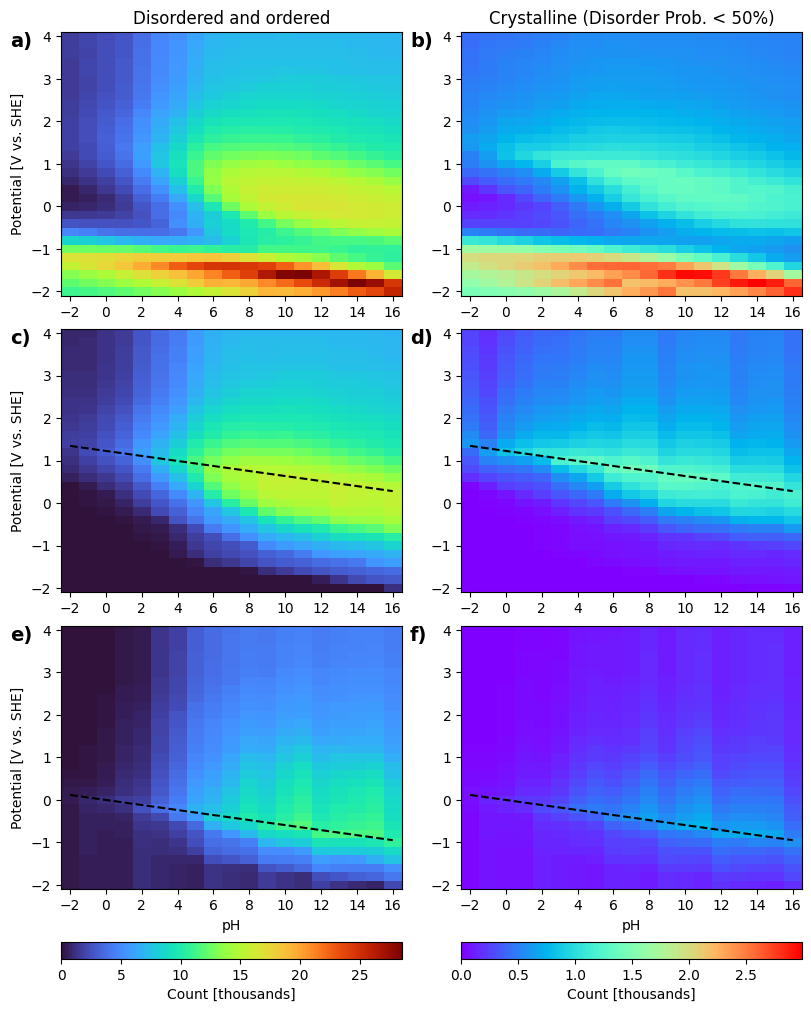

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

fig, axes = plt.subplots(3, 2, figsize=(8, 10), constrained_layout=True)

# Transpose so axes[0] = left column, axes[1] = right column
axes = axes.T  

cm1 = 'turbo'
cm2 = 'rainbow'

scale_norm = 1000

count_plot = count / scale_norm
count_crystalline_plot = count_crystalline / scale_norm
O_line_count_plot = O_line_count / scale_norm
O_line_count_ordered_plot = O_line_count_ordered / scale_norm
H_line_count_plot = H_line_count / scale_norm
H_line_count_ordered_plot = H_line_count_ordered / scale_norm

# Column-wise normalizations
norm_col1 = Normalize(
    vmin=0,
    vmax=np.max([count_plot, O_line_count_plot, H_line_count_plot])
)
norm_col2 = Normalize(
    vmin=0,
    vmax=np.max([count_crystalline_plot, O_line_count_ordered_plot, H_line_count_ordered_plot])
)

# Images grouped by column
images_col1 = [
    count_plot + 1e-8,
    O_line_count_plot + 1e-8,
    H_line_count_plot + 1e-8
]

images_col2 = [
    count_crystalline_plot + 1e-8,
    O_line_count_ordered_plot + 1e-8,
    H_line_count_ordered_plot + 1e-8
]

labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)']

# Lines
O_line = np.linspace(1.3482, 0.2844, 2)
H_line = np.linspace(0.1182, -0.9456, 2)

meshes = []

# ---- COLUMN LOOP ----
for col_idx, (col_axes, col_images, norm) in enumerate(
    zip(axes, [images_col1, images_col2], [norm_col1, norm_col2])
):
    for row_idx, (ax, data) in enumerate(zip(col_axes, col_images)):
        mesh = ax.pcolormesh(
            pHs, Us, data,
            cmap = cm1 if col_idx == 0 else cm2,
            norm=norm,
            shading='auto',
        )
        meshes.append(mesh)
        
        if row_idx == 0 and col_idx == 0:
            ax.set_title('Disordered and ordered')
        elif row_idx == 0 and col_idx == 1:
            ax.set_title('Crystalline (Disorder Prob. < 50%)')

        if row_idx == 2:
            ax.set_xlabel('pH')
        if col_idx == 0:
            ax.set_ylabel('Potential [V vs. SHE]')

        ax.set_xticks(np.arange(-2, 17, 2))
        ax.set_yticks(np.arange(-2, 5, 1))
        # ax.set_aspect('auto')

        # Overlay lines
        if row_idx == 1:
            ax.plot([-2, 16], O_line, 'k--', linewidth=1.5)
        if row_idx == 2:
            ax.plot([-2, 16], H_line, 'k--', linewidth=1.5)

        # Subplot labels
        label_idx = row_idx * 2 + col_idx
        ax.text(
            -0.15, 1.0, labels[label_idx],
            transform=ax.transAxes,
            fontsize=14, fontweight='bold',
            va='top', ha='left'
        )

    # ---- COLORBAR UNDER EACH COLUMN ----
    cbar = fig.colorbar(
        mesh,
        ax=col_axes,
        orientation='horizontal',
        fraction=0.07,
        pad=0.01
    )
    cbar.set_label('Count [thousands]')

# fig.savefig('Stability_hist_02_all.pdf')

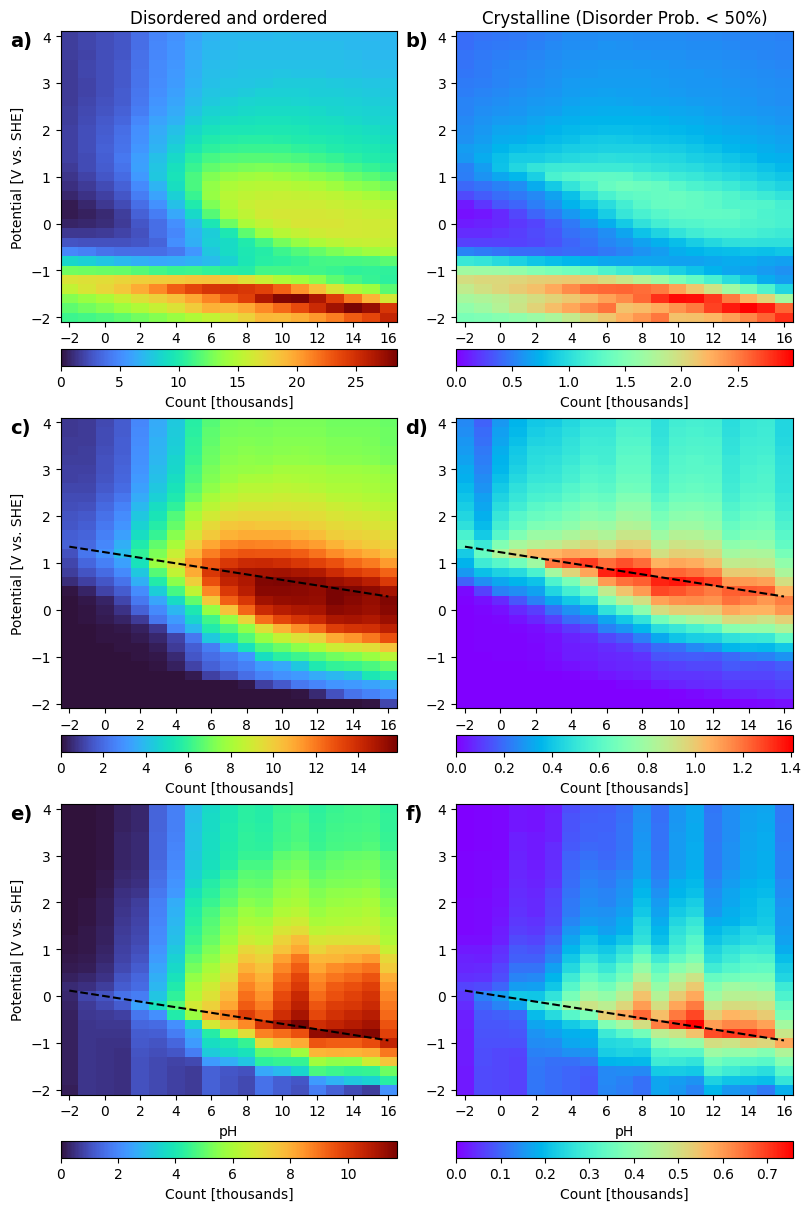

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

fig, axes = plt.subplots(3, 2, figsize=(8, 12), constrained_layout=True)

# Transpose so axes[0] = left column, axes[1] = right column
axes = axes.T  

cm1 = 'turbo'
cm2 = 'rainbow'

scale_norm = 1000

count_plot = count / scale_norm
count_crystalline_plot = count_crystalline / scale_norm
O_line_count_plot = O_line_count / scale_norm
O_line_count_ordered_plot = O_line_count_ordered / scale_norm
H_line_count_plot = H_line_count / scale_norm
H_line_count_ordered_plot = H_line_count_ordered / scale_norm

# Images grouped by column
images_col1 = [
    count_plot + 1e-8,
    O_line_count_plot + 1e-8,
    H_line_count_plot + 1e-8
]

images_col2 = [
    count_crystalline_plot + 1e-8,
    O_line_count_ordered_plot + 1e-8,
    H_line_count_ordered_plot + 1e-8
]

labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)']

# Lines
O_line = np.linspace(1.3482, 0.2844, 2)
H_line = np.linspace(0.1182, -0.9456, 2)

# ---- COLUMN LOOP ----
for col_idx, (col_axes, col_images) in enumerate(
    zip(axes, [images_col1, images_col2])
):
    for row_idx, (ax, data) in enumerate(zip(col_axes, col_images)):
        # Per-plot normalization
        norm = Normalize(vmin=0, vmax=np.max(data))

        mesh = ax.pcolormesh(
            pHs, Us, data,
            cmap=cm1 if col_idx == 0 else cm2,
            norm=norm,
            shading='auto',
        )

        if row_idx == 0 and col_idx == 0:
            ax.set_title('Disordered and ordered')
        elif row_idx == 0 and col_idx == 1:
            ax.set_title('Crystalline (Disorder Prob. < 50%)')

        if row_idx == 2:
            ax.set_xlabel('pH')
        if col_idx == 0:
            ax.set_ylabel('Potential [V vs. SHE]')

        ax.set_xticks(np.arange(-2, 17, 2))
        ax.set_yticks(np.arange(-2, 5, 1))

        # Overlay lines
        if row_idx == 1:
            ax.plot([-2, 16], O_line, 'k--', linewidth=1.5)
        if row_idx == 2:
            ax.plot([-2, 16], H_line, 'k--', linewidth=1.5)

        # Subplot labels
        label_idx = row_idx * 2 + col_idx
        ax.text(
            -0.15, 1.0, labels[label_idx],
            transform=ax.transAxes,
            fontsize=14, fontweight='bold',
            va='top', ha='left'
        )

        # ---- COLORBAR PER PLOT ----
        cbar = fig.colorbar(
            mesh,
            ax=ax,
            orientation='horizontal',
            fraction=0.07,
            pad=0.01
        )
        cbar.set_label('Count [thousands]')

fig.savefig('Stability_hist_02_excluding_elements.pdf')

### pbx stability criteria

In [40]:

from pymatgen.core import Composition

def is_balanced_groups(composition_str: str, 
                       group1: list[str], 
                       group2: list[str],
                       fractional_limit: float) -> bool:
    """Check if composition has equal atom counts from group1 and group2."""
    comp = Composition(composition_str)
    element_dict = comp.get_el_amt_dict()
    
    group1_count = sum(element_dict.get(el, 0) for el in group1)
    group2_count = sum(element_dict.get(el, 0) for el in group2)
    
    if group1_count == 0 or group2_count == 0:
        return False
    
    if np.isclose(fractional_limit, 0):
        return group1_count == group2_count
    else:
        diff = np.abs(group1_count - group2_count)
        ratio = diff / (group1_count + group2_count)
        return ratio <= fractional_limit

def get_df_eCO2RR_candidates_and_se(elements_to_exclude):
    dh = Data_Handler(solid_filter = True, gga_only = False, path_to_data_directory = None)
    dh.restore_df()
    dh.remove_entries_with_elements(elements_to_exclude)
    se = Stable_Entries(dh, [])

    strong_binding_elements = ['Ti', 'Ni', 'Pd', 'Pt', 'Ru', 'Rh', 'Ir', 'Fe']
    weak_binding_elements = ['Zn', 'Ag', 'Au', 'In', 'Sn']

    elements_whic_must_be_included = weak_binding_elements + strong_binding_elements

    dh.remove_entries_with_elements(elements_to_exclude)
    dh.remove_entries_without_elements(elements_whic_must_be_included, False)

    df = dh.get_df()

    df = df[df['Composition'].apply(
        lambda x: is_balanced_groups(x, strong_binding_elements, weak_binding_elements,
                                                                fractional_limit=.5))]

    return df, se

def get_df_eCO2RR_candidates_and_se_SI(elements_to_exclude):
    dh = Data_Handler(solid_filter = True, gga_only = False, path_to_data_directory = None)
    dh.restore_df()
    dh.remove_entries_with_elements(elements_to_exclude)
    se = Stable_Entries(dh, [])

    strong_binding_elements = ['Ti', 'Ni', 'Pd', 'Pt', 'Ru', 'Rh', 'Ir', 'Fe']
    weak_binding_elements = ['Zn', 'Ag', 'Au', 'In', 'Sn']

    elements_whic_must_be_included = weak_binding_elements + strong_binding_elements

    dh.remove_entries_with_elements(elements_to_exclude)
    dh.remove_entries_without_elements(elements_whic_must_be_included, False)

    df = dh.get_df()

    df = df[df['Composition'].apply(
        lambda x: is_balanced_groups(x, strong_binding_elements, weak_binding_elements,
                                                                fractional_limit=0))]

    return df, se

In [41]:
S = []
SO = []

lims = np.linspace(0.0001, 0.5, 101)
lims = lims[::-1]
lims

type_i = 0
spaces = ['Ir-OER-solid-filter', 'Ir-OER', 'eCO2RR']
for interval in ([16, 21, 2], [16, 21, 2], [0, 9, 9]):
    print('\nspace:', spaces[type_i])
    if type_i == 0:
        dh = Data_Handler(solid_filter = True, gga_only = False, path_to_data_directory = None)
        se = Stable_Entries(dh, [])
        dh.remove_entries_with_elements(elements_to_exclude)
        dh.remove_entries_without_elements(['Ir'], True)
        iter_df = dh.get_df()
    elif type_i == 1:
        dh = Data_Handler(solid_filter = False, gga_only = False, path_to_data_directory = None)
        se = Stable_Entries(dh, [])
        dh.remove_entries_with_elements(elements_to_exclude)
        dh.remove_entries_without_elements(['Ir'], True)
        iter_df = dh.get_df()
    else:
        iter_df, se = get_df_eCO2RR_candidates_and_se(elements_to_exclude)


    num_stable = []
    num_stable_and_ordered = []
    first = True
    for lim in lims:
        indeces_to_remove = []

        for i, row in iter_df.iterrows():

            decom_G = se.get_decom_G(row)
            decom_G_line = decom_G[interval[0]:interval[1], interval[2]] 
            

            if not all(decom_G_line < lim):
                indeces_to_remove.append(i)

        iter_df = iter_df.drop(index=indeces_to_remove)
        num_stable.append(len(iter_df))
        num_stable_and_ordered.append(len(
            iter_df[iter_df['Disorder Probability'] < 0.5]))

        if first:
            first = False
            print(f'Limit: {lim:.4f}, number of stable entries: {len(iter_df)}')
        else:
            print(f'Limit: {lim:.4f}, number of stable entries: {len(iter_df)}          ', end='\r')

    S.append(num_stable)
    SO.append(num_stable_and_ordered)
    type_i += 1


space: Ir-OER-solid-filter
Mixed GGA/GGA(+U)/r2SCAN results will be used for stability analysis.
Number of entries removed: 283529 Number of entries left: 245442 which is 46.40% of total GNoME database
Removed all entries not containing all of the following elements: Ir .Number of entries removed: 203752 Number of entries left: 41690 which is 7.88% of total GNoME database
Limit: 0.5000, number of stable entries: 1412
Limit: 0.0001, number of stable entries: 1             
space: Ir-OER
Mixed GGA/GGA(+U)/r2SCAN results will be used for stability analysis.
Number of entries removed: 283529 Number of entries left: 245442 which is 46.40% of total GNoME database
Removed all entries not containing all of the following elements: Ir .Number of entries removed: 203752 Number of entries left: 41690 which is 7.88% of total GNoME database
Limit: 0.5000, number of stable entries: 937
Limit: 0.0001, number of stable entries: 0            
space: eCO2RR
Number of entries removed: 283529 Number of en

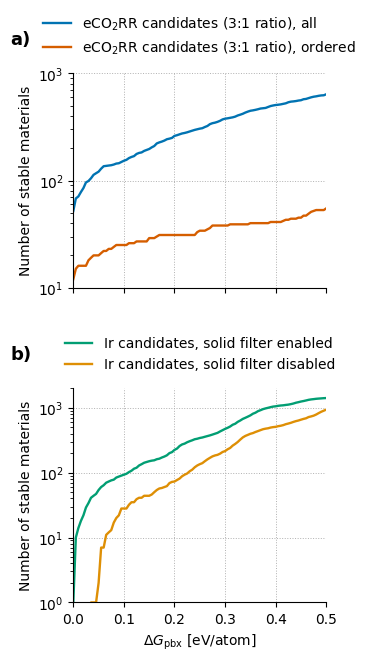

In [50]:
# num_stable_ORR = num_stable.copy()

# plt.rcParams["text.usetex"] = True

num_stable_Ir_ordered_OER = num_stable.copy()

fig, ax = plt.subplots(2, 1, figsize=(3.6, 6.5), sharex=True,
                       constrained_layout=True)
fig.get_layout_engine().set(hspace=0.1)


lw = 1.7
ax[0].plot(lims, S[2], '-', color = col_list[0], linewidth=lw, 
           label=r'eCO$_2$RR candidates (3:1 ratio), all')
ax[0].plot(lims, SO[2], '-', color = col_list[3], linewidth=lw, 
            label=r'eCO$_2$RR candidates (3:1 ratio), ordered')
ax[1].plot(lims, S[0], '-', color = col_list[2], linewidth=lw, 
            label=r'Ir candidates, solid filter enabled')
ax[1].plot(lims, S[1], '-', color = col_list[1], linewidth=lw, 
            label=r'Ir candidates, solid filter disabled')




for a in ax:
    a.set_xlim(0, 0.5)
    a.grid(linestyle=':', linewidth=0.7)
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.legend(
        loc='lower center',
        bbox_to_anchor=(0.5, 1.02),
        frameon=False
    )
    a.set_yscale('log')
    a.set_ylabel('Number of stable materials')
    
ax[0].set_ylim(10, 1000)
ax[1].set_ylim(1, 2000)

# handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(handles, labels,
#            loc='upper center',
#            ncol=1,
#            frameon=False,
#            bbox_to_anchor=(0.5, 1.1))

ax[0].text(-0.25, 1.2, 'a)', transform=ax[0].transAxes,
           fontsize=13, fontweight='bold', va='top')
ax[1].text(-0.25, 1.2, 'b)', transform=ax[1].transAxes,
           fontsize=13, fontweight='bold', va='top')

ax[1].set_xlabel(r'$\Delta G_{\mathrm{pbx}}\ \mathrm{[eV/atom]}$')
# fig.tight_layout()
fig.savefig('num_stable_vs_stability_criteria.pdf',
            bbox_inches='tight'
)

fig.savefig('num_stable_vs_stability_criteria.png')

In [51]:
S = []
SO = []

lims = np.linspace(0.0001, 0.5, 101)
lims = lims[::-1]
lims

type_i = 0
spaces = ['eCO2RR']
for interval in ([[0, 9, 9]]):
    print('\nspace:', spaces[type_i])
    iter_df, se = get_df_eCO2RR_candidates_and_se_SI(elements_to_exclude)


    num_stable = []
    num_stable_and_ordered = []
    first = True
    for lim in lims:
        indeces_to_remove = []

        for i, row in iter_df.iterrows():

            decom_G = se.get_decom_G(row)
            decom_G_line = decom_G[interval[0]:interval[1], interval[2]] 
            

            if not all(decom_G_line < lim):
                indeces_to_remove.append(i)

        iter_df = iter_df.drop(index=indeces_to_remove)
        num_stable.append(len(iter_df))
        num_stable_and_ordered.append(len(
            iter_df[iter_df['Disorder Probability'] < 0.5]))

        if first:
            first = False
            print(f'Limit: {lim:.4f}, number of stable entries: {len(iter_df)}')
        else:
            print(f'Limit: {lim:.4f}, number of stable entries: {len(iter_df)}          ', end='\r')

    S.append(num_stable)
    SO.append(num_stable_and_ordered)
    type_i += 1


space: eCO2RR
Number of entries removed: 283529 Number of entries left: 245442 which is 46.40% of total GNoME database
Mixed GGA/GGA(+U)/r2SCAN results will be used for stability analysis.
Number of entries removed: 0 Number of entries left: 245442 which is 46.40% of total GNoME database
Removed all entries not containing any of the following elements: Zn, Ag, Au, In, Sn, Ti, Ni, Pd, Pt, Ru, Rh, Ir, Fe .Number of entries removed: 60439 Number of entries left: 185003 which is 34.97% of total GNoME database
Limit: 0.5000, number of stable entries: 63


C:\Users\matnis\AppData\Local\Temp\ipykernel_15268\2608556955.py:9: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=2)


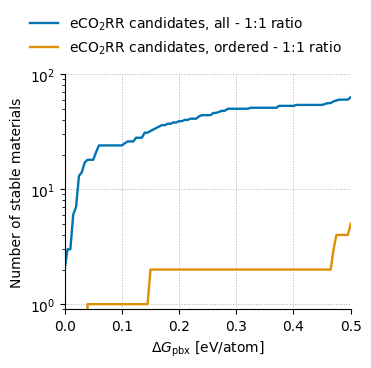

In [52]:
# num_stable_ORR = num_stable.copy()

# plt.rcParams["text.usetex"] = True

num_stable_Ir_ordered_OER = num_stable.copy()

fig, ax = plt.subplots(1, 1, figsize=(3.6, 3), sharex=True,
                       constrained_layout=True  )
fig.subplots_adjust(hspace=2)

lw = 1.7
ax.plot(lims, S[0], '-', color = col_list[0], linewidth=lw, 
           label=r'eCO$_2$RR candidates, all - 1:1 ratio')
ax.plot(lims, SO[0], '-', color = col_list[1], linewidth=lw, 
           label=r'eCO$_2$RR candidates, ordered - 1:1 ratio')


ax.set_ylabel('Number of stable materials')

ax.set_xlim(0, 0.5)
ax.set_ylim(0.9, 100)
ax.grid(linestyle=':')
ax.set_yscale('log')
ax.grid(linestyle=':')
ax.grid(linestyle=':', linewidth=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper center',
           ncol=1,
           frameon=False,
           bbox_to_anchor=(0.5, 1.2))

ax.set_xlabel(r'$\Delta G_{\mathrm{pbx}}\ \mathrm{[eV/atom]}$')
fig.savefig('num_stable_vs_stability_criteria_11_SI.pdf',
            bbox_inches='tight'
)

IndexError: list index out of range

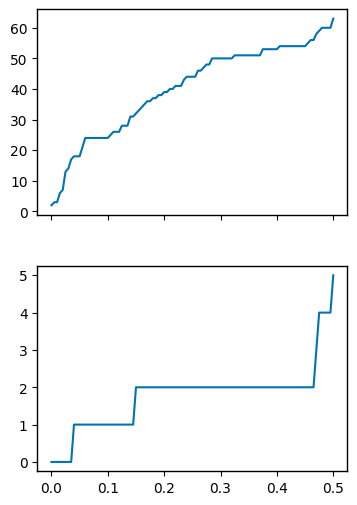

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Global style (publication-friendly)
# -------------------------
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 1.0
})

# -------------------------
# Create figure
# -------------------------
fig, ax = plt.subplots(2, 1, figsize=(4, 6), sharex=True,  gridspec_kw={'hspace': 0.25})
# -------------------------
# Plot data
# -------------------------
lw = 2  # thicker lines for publication

ax[0].plot(lims, S[0], '-',  color=col_list[0],# linewidth=lw,
           label='Stability interval [1.2–2.0] V, OER')
ax[1].plot(lims, SO[0], color=col_list[0],# linewidth=lw,
           label='Stability interval [1.2–2.0] V, ordered, OER')

ax[0].plot(lims, S[1], '-',  color=col_list[2],# linewidth=lw,
           label='Stability interval [0.6–1.2] V, eCO$_2$RR')
ax[1].plot(lims, SO[1], color=col_list[2],# linewidth=lw,
           label='Stability interval [0.6–1.2] V, ordered, eCO$_2$RR')

# -------------------------
# Formatting
# -------------------------
for a in ax:
    a.set_xlim(0, 0.5)
    a.grid(linestyle=':', linewidth=0.7)
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

    
    # Clean look
    # a.spines['top'].set_visible(False)
    # a.spines['right'].set_visible(False)

# Subplot labels
ax[0].text(-0.075, 0.95, 'a)', transform=ax[0].transAxes,
           fontsize=13, fontweight='bold', va='top')
ax[1].text(-0.075, 0.95, 'b)', transform=ax[1].transAxes,
           fontsize=13, fontweight='bold', va='top')

ax[0].set_ylabel('Count stable')
ax[1].set_ylabel('Count stable and ordered')
ax[1].set_xlabel('Stability citeria [eV/atom]')

# -------------------------
# Single shared legend (top center)
# -------------------------
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper center',
           ncol=1,
           frameon=False,
           bbox_to_anchor=(0.5, 0.975))

# -------------------------
# Tight layout & save
# -------------------------
fig.tight_layout()
fig.savefig('num_stable_vs_stability_criteria.pdf',
            transparent=True)

plt.show()

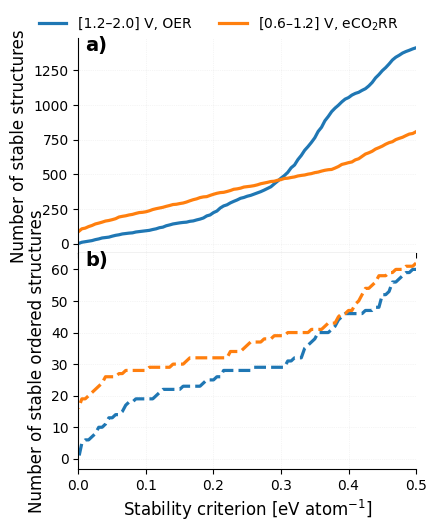

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Clean publication style
# -------------------------
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8
})

# -------------------------
# Figure
# -------------------------
fig, ax = plt.subplots(
    2, 1,
    figsize=(4.5, 5.2),
    sharex=True,
    gridspec_kw={'hspace': 0}
)

# Force white background
fig.patch.set_facecolor('white')
for a in ax:
    a.set_facecolor('white')

# -------------------------
# Plot
# -------------------------
lw = 2.3

ax[0].plot(lims, S[0], '-', linewidth=lw,
           label='[1.2–2.0] V, OER')
ax[0].plot(lims, S[1], '-', linewidth=lw,
           label='[0.6–1.2] V, eCO$_2$RR')

ax[1].plot(lims, SO[0], '--', linewidth=lw)
ax[1].plot(lims, SO[1], '--', linewidth=lw)

# -------------------------
# Formatting
# -------------------------
for a in ax:
    a.set_xlim(0, 0.5)
    
    # Very subtle grid (optional — remove if desired)
    a.grid(True, linestyle=':', linewidth=0.5, alpha=0.25)
    
    # Clean spines
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

ax[0].set_ylabel('Number of stable structures')
ax[1].set_ylabel('Number of stable ordered structures')
ax[1].set_xlabel(r'Stability criterion [eV atom$^{-1}$]')

ax[0].tick_params(labelbottom=False)

# Panel labels
ax[0].text(0.02, 0.94, 'a)', transform=ax[0].transAxes,
           fontsize=14, fontweight='bold')
ax[1].text(0.02, 0.94, 'b)', transform=ax[1].transAxes,
           fontsize=14, fontweight='bold')

# Legend (only from top panel)
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper center',
           ncol=2,
           frameon=False,
           bbox_to_anchor=(0.5, 1.03))

# Layout
fig.tight_layout()
fig.savefig("num_stable_vs_stability_criteria.pdf",
            dpi=600,
            bbox_inches='tight')

plt.show()